# HGT experiment: single context features

Ноутбук для эксперимента “каждый признак отдельно”: `raw` и `raw + один контекстный признак`. Весь общий HGT-код импортируется из `hgt_common.py`.

In [1]:
from pathlib import Path
import sys

sys.path.append(str(Path.cwd()))

from hgt_common import *

DATA_DIR = Path("..")  # поменяй на Path(".") или абсолютный путь при необходимости
CFG = HGTExperimentConfig(
    k_values=[20],
    target_metrics=["recall", "ndcg"],
    epochs=100,
)
set_seed(CFG.seed)
log_step(f"device: {CFG.device}")
log_step(f"target k_values: {CFG.k_values}")
log_step(f"target metrics: {CFG.target_metrics}")

tables = load_hgt_tables(DATA_DIR)
runner = make_hgt_runner(tables, CFG)


[14:01:02] device: cpu
[14:01:02] target k_values: [20]
[14:01:02] target metrics: ['recall', 'ndcg']


/Users/alexandro/DataspellProjects/recommend-system/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[14:01:02] loaded rates: (948367, 4)
[14:01:02] loaded users: (6040, 4)
[14:01:02] loaded movies: (3433, 7)
[14:01:02] loaded movie_genres: (6408, 2)
[14:01:02] loaded movie_actors: (10285, 2)
[14:01:02] loaded movie_directors: (3676, 2)
[14:01:02] loaded movie_countries: (4765, 2)
[14:01:02] loaded movie_tags: (450912, 2)


## Влияние каждого признака отдельно

Каждый контекстный признак сравнивается с `raw`: только взаимодействия + один тип связи.

In [2]:
from pathlib import Path

SINGLE_CONTEXT_STAGES = [
    "raw",
    "genres",
    "directors",
    "actors",
    "countries",
    "tags",
    "age_group",
    "occupation",
]

TARGET_K = 20
TARGET_METRICS = ["recall", "ndcg"]

SINGLE_CONTEXT_RESULTS_PATH = Path("exp_results/hgt_single_context_recall20_ndcg20_results.csv")
SINGLE_CONTEXT_DELTAS_PATH = Path("exp_results/hgt_single_context_recall20_ndcg20_deltas_long.csv")


def load_single_context_results(path=SINGLE_CONTEXT_RESULTS_PATH):
    if path.exists():
        return pd.read_csv(path)

    return pd.DataFrame()


def _detect_metric_columns(df: pd.DataFrame):
    return [col for col in TARGET_METRICS if col in df.columns]


def _keep_target_metric_columns(df: pd.DataFrame) -> pd.DataFrame:
    keep_cols = [
        "stage",
        "threshold",
        "min_pos",
        "k",
        "context_feature",
        *TARGET_METRICS,
        "n_users_eval",
    ]
    return df[[col for col in keep_cols if col in df.columns]].copy()


def save_single_context_result_incrementally(new_df, path=SINGLE_CONTEXT_RESULTS_PATH):
    new_df = _keep_target_metric_columns(new_df)

    if path.exists():
        old_df = pd.read_csv(path)
        result_df = pd.concat([old_df, new_df], ignore_index=True)
    else:
        result_df = new_df.copy()

    result_df = result_df.drop_duplicates(
        subset=["stage", "threshold", "min_pos", "k"],
        keep="last",
    )

    result_df = result_df.sort_values(
        ["threshold", "min_pos", "stage", "k"]
    ).reset_index(drop=True)

    result_df.to_csv(path, index=False)
    log_step(f"saved results -> {path}; rows={len(result_df)}")
    return result_df


def build_single_context_deltas_long(results_df: pd.DataFrame, path=SINGLE_CONTEXT_DELTAS_PATH):
    metric_cols = _detect_metric_columns(results_df)

    base_df = results_df[results_df["stage"] == "raw"].copy()
    if base_df.empty:
        raise ValueError("Нет строки stage='raw'. Сначала нужно запустить базовый эксперимент.")

    rows = []

    for _, row in results_df.iterrows():
        base_match = base_df[
            (base_df["threshold"] == row["threshold"]) &
            (base_df["min_pos"] == row["min_pos"]) &
            (base_df["k"] == row["k"])
        ]

        if base_match.empty:
            continue

        base_row = base_match.iloc[0]

        for metric in metric_cols:
            value = float(row[metric])
            raw_value = float(base_row[metric])

            rows.append({
                "stage": row["stage"],
                "context_feature": row.get("context_feature", row["stage"]),
                "threshold": row["threshold"],
                "min_pos": row["min_pos"],
                "k": row["k"],
                "metric": metric,
                "value": value,
                "raw_value": raw_value,
                "delta_vs_raw": value - raw_value,
            })

    deltas_df = pd.DataFrame(rows)
    deltas_df.to_csv(path, index=False)
    log_step(f"saved deltas -> {path}; rows={len(deltas_df)}")
    return deltas_df


def run_single_context_experiments(
        runner,
        stages=SINGLE_CONTEXT_STAGES,
        threshold=5.0,
        min_pos=5,
        target_k=TARGET_K,
        results_path=SINGLE_CONTEXT_RESULTS_PATH,
):
    log_step("single-context experiments started")
    log_step(f"stages={stages}")
    log_step(f"metrics={[metric + '@' + str(target_k) for metric in TARGET_METRICS]}")
    log_step(f"threshold={threshold}, min_pos={min_pos}")

    existing_df = load_single_context_results(results_path)

    completed_stages = set()
    if not existing_df.empty:
        mask = (
            (existing_df["threshold"] == threshold) &
            (existing_df["min_pos"] == min_pos) &
            (existing_df["k"] == target_k)
        )
        completed_stages = set(existing_df.loc[mask, "stage"].astype(str).unique())

    log_step(f"already completed stages: {sorted(completed_stages)}")

    total_stages = len(stages)
    for stage_idx, stage in enumerate(stages, start=1):
        if stage in completed_stages:
            log_step(f"[{stage_idx}/{total_stages}] SKIP stage={stage}: result already saved")
            continue

        print("\n" + "=" * 90)
        log_step(f"[{stage_idx}/{total_stages}] START stage={stage}")
        print("=" * 90)

        # Сбрасываем seed перед каждым запуском, чтобы снизить шум от случайной инициализации
        # и negative sampling. Полностью идентичными модели всё равно не будут, так как графы разные.
        set_seed(runner.config.seed)
        log_step(f"stage={stage}: seed reset to {runner.config.seed}")

        stage_started_at = time.time()
        result_df, _ = runner.run_temporal_80_20(
            stage=stage,
            threshold=threshold,
            min_pos=min_pos,
        )

        result_df = result_df[result_df["k"] == target_k].copy()
        result_df["threshold"] = threshold
        result_df["min_pos"] = min_pos
        result_df["context_feature"] = "raw" if stage == "raw" else stage
        result_df = _keep_target_metric_columns(result_df)

        current_df = save_single_context_result_incrementally(
            result_df,
            path=results_path,
        )

        deltas_df = build_single_context_deltas_long(current_df)

        preview_cols = ["stage", "k", *TARGET_METRICS, "n_users_eval"]
        log_step(f"[{stage_idx}/{total_stages}] FINISH stage={stage}; elapsed={(time.time() - stage_started_at) / 60:.2f} min")
        display(result_df[[col for col in preview_cols if col in result_df.columns]])

    final_results_df = load_single_context_results(results_path)
    final_deltas_df = build_single_context_deltas_long(final_results_df)
    log_step("single-context experiments finished")

    return final_results_df, final_deltas_df


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

CONTEXT_LABELS_RU = {
    "raw": "Без контекста",
    "genres": "Жанры",
    "directors": "Режиссёры",
    "actors": "Актёры",
    "countries": "Страны",
    "tags": "Теги",
    "age_group": "Возрастная группа",
    "occupation": "Род занятий",
}

METRIC_LABELS_RU = {
    "recall": "Recall",
    "ndcg": "NDCG",
}


def plot_single_context_metric(
        deltas_df: pd.DataFrame,
        metric="recall",
        k=20,
        threshold=5.0,
        min_pos=5,
        show_delta=True,
):
    if metric not in TARGET_METRICS:
        raise ValueError(f"Для этого эксперимента доступны только метрики: {TARGET_METRICS}")

    plot_df = deltas_df[
        (deltas_df["metric"] == metric) &
        (deltas_df["k"] == k) &
        (deltas_df["threshold"] == threshold) &
        (deltas_df["min_pos"] == min_pos)
    ].copy()

    plot_df["context_label"] = plot_df["stage"].map(CONTEXT_LABELS_RU).fillna(plot_df["stage"])

    order = [
        CONTEXT_LABELS_RU[stage]
        for stage in SINGLE_CONTEXT_STAGES
        if stage in set(plot_df["stage"])
    ]

    y_col = "delta_vs_raw" if show_delta else "value"
    ylabel = (
        f"Δ {METRIC_LABELS_RU.get(metric, metric)}@{k} относительно raw"
        if show_delta
        else f"{METRIC_LABELS_RU.get(metric, metric)}@{k}"
    )

    plt.figure(figsize=(11, 6))

    ax = sns.barplot(
        data=plot_df,
        x="context_label",
        y=y_col,
        order=order,
    )

    plt.title(
        f"Влияние отдельных контекстных признаков на {METRIC_LABELS_RU.get(metric, metric)}@{k}"
    )
    plt.xlabel("Контекстный признак")
    plt.ylabel(ylabel)
    plt.xticks(rotation=30, ha="right")
    plt.grid(axis="y", alpha=0.3)

    if show_delta:
        ax.axhline(0, linewidth=1)

    plt.tight_layout()
    plt.show()


In [4]:
single_context_results, single_context_deltas = run_single_context_experiments(
    runner=runner,
    stages=SINGLE_CONTEXT_STAGES,
    threshold=5.0,
    min_pos=5,
    target_k=20,
)

display(single_context_results)
display(single_context_deltas)

[14:01:02] single-context experiments started
[14:01:02] stages=['raw', 'genres', 'directors', 'actors', 'countries', 'tags', 'age_group', 'occupation']
[14:01:02] metrics=['recall@20', 'ndcg@20']
[14:01:02] threshold=5.0, min_pos=5
[14:01:02] already completed stages: []

[14:01:02] [1/8] START stage=raw
[14:01:02] stage=raw: seed reset to 42
[14:01:02] stage=raw: preparing temporal 80/20 split; threshold=5.0, min_pos=5
[14:01:03] stage=raw: positive stats
users_total    5614.0
min               5.0
p25              13.0
median           24.0
p75              48.0
max             533.0
users_lt5         0.0
users_lt10      868.0
users_lt20     2332.0
dtype: float64
[14:01:03] stage=raw: train/test shapes: train=(168107, 3), test=(44791, 3)
[14:01:03] stage=raw: fit started; k_values=[20]; target_metrics=['recall', 'ndcg']
[14:01:03] stage=raw: building index maps
[14:01:03] context: filtering context tables by train movies
[14:01:03] context sizes after filtering: genres=4908, directo

,stage,k,recall,ndcg,n_users_eval
0,raw,20,0.145099,0.097156,5614



[14:38:02] [2/8] START stage=genres
[14:38:02] stage=genres: seed reset to 42
[14:38:02] stage=genres: preparing temporal 80/20 split; threshold=5.0, min_pos=5
[14:38:03] stage=genres: positive stats
users_total    5614.0
min               5.0
p25              13.0
median           24.0
p75              48.0
max             533.0
users_lt5         0.0
users_lt10      868.0
users_lt20     2332.0
dtype: float64
[14:38:03] stage=genres: train/test shapes: train=(168107, 3), test=(44791, 3)
[14:38:03] stage=genres: fit started; k_values=[20]; target_metrics=['recall', 'ndcg']
[14:38:03] stage=genres: building index maps
[14:38:03] context: filtering context tables by train movies
[14:38:03] context sizes after filtering: genres=4908, directors=1747, actors=3675, countries=3952, tags=209972
[14:38:03] stage=genres: building HeteroData
[14:38:03] stage=genres: graph moved to device=cpu
[14:38:03] stage=genres: node types=['user', 'movie', 'genre']
[14:38:03] stage=genres: edge types=[('user

,stage,k,recall,ndcg,n_users_eval
0,genres,20,0.146262,0.096911,5614



[15:16:58] [3/8] START stage=directors
[15:16:58] stage=directors: seed reset to 42
[15:16:58] stage=directors: preparing temporal 80/20 split; threshold=5.0, min_pos=5
[15:16:58] stage=directors: positive stats
users_total    5614.0
min               5.0
p25              13.0
median           24.0
p75              48.0
max             533.0
users_lt5         0.0
users_lt10      868.0
users_lt20     2332.0
dtype: float64
[15:16:58] stage=directors: train/test shapes: train=(168107, 3), test=(44791, 3)
[15:16:58] stage=directors: fit started; k_values=[20]; target_metrics=['recall', 'ndcg']
[15:16:58] stage=directors: building index maps
[15:16:58] context: filtering context tables by train movies
[15:16:58] context sizes after filtering: genres=4908, directors=1747, actors=3675, countries=3952, tags=209972
[15:16:58] stage=directors: building HeteroData
[15:16:58] stage=directors: graph moved to device=cpu
[15:16:58] stage=directors: node types=['user', 'movie', 'director']
[15:16:58]

...


[19:11:09] [8/8] START stage=occupation
[19:11:09] stage=occupation: seed reset to 42
[19:11:09] stage=occupation: preparing temporal 80/20 split; threshold=5.0, min_pos=5
[19:11:09] stage=occupation: positive stats
users_total    5614.0
min               5.0
p25              13.0
median           24.0
p75              48.0
max             533.0
users_lt5         0.0
users_lt10      868.0
users_lt20     2332.0
dtype: float64
[19:11:09] stage=occupation: train/test shapes: train=(168107, 3), test=(44791, 3)
[19:11:09] stage=occupation: fit started; k_values=[20]; target_metrics=['recall', 'ndcg']
[19:11:09] stage=occupation: building index maps
[19:11:09] context: filtering context tables by train movies
[19:11:09] context sizes after filtering: genres=4908, directors=1747, actors=3675, countries=3952, tags=209972
[19:11:09] stage=occupation: building HeteroData
[19:11:09] stage=occupation: graph moved to device=cpu
[19:11:09] stage=occupation: node types=['user', 'movie', 'occupation'

,stage,k,recall,ndcg,n_users_eval
0,occupation,20,0.144525,0.097007,5614


[19:50:23] saved deltas -> hgt_single_context_recall20_ndcg20_deltas_long.csv; rows=16
[19:50:23] single-context experiments finished


,stage,threshold,min_pos,k,context_feature,recall,ndcg,n_users_eval
0,actors,5.0,5,20,actors,0.145919,0.097363,5614
1,age_group,5.0,5,20,age_group,0.139724,0.094705,5614
2,countries,5.0,5,20,countries,0.148234,0.098546,5614
3,directors,5.0,5,20,directors,0.147936,0.098877,5614
4,genres,5.0,5,20,genres,0.146262,0.096911,5614
5,occupation,5.0,5,20,occupation,0.144525,0.097007,5614
6,raw,5.0,5,20,raw,0.145099,0.097156,5614
7,tags,5.0,5,20,tags,0.144757,0.096615,5614


,stage,context_feature,threshold,min_pos,k,metric,value,raw_value,delta_vs_raw
0,actors,actors,5.0,5,20,recall,0.145919,0.145099,0.000819
1,actors,actors,5.0,5,20,ndcg,0.097363,0.097156,0.000207
2,age_group,age_group,5.0,5,20,recall,0.139724,0.145099,-0.005375
3,age_group,age_group,5.0,5,20,ndcg,0.094705,0.097156,-0.002451
4,countries,countries,5.0,5,20,recall,0.148234,0.145099,0.003135
5,countries,countries,5.0,5,20,ndcg,0.098546,0.097156,0.001390
6,directors,directors,5.0,5,20,recall,0.147936,0.145099,0.002837
7,directors,directors,5.0,5,20,ndcg,0.098877,0.097156,0.001721
8,genres,genres,5.0,5,20,recall,0.146262,0.145099,0.001162
9,genres,genres,5.0,5,20,ndcg,0.096911,0.097156,-0.000245


In [22]:
import pandas as pd
import matplotlib.pyplot as plt

# ===== Пути к файлам =====
results_path = "exp_results/hgt_single_context_recall20_ndcg20_results.csv"
deltas_path = "exp_results/hgt_single_context_recall20_ndcg20_deltas_long.csv"

# ===== Загрузка =====
results_df = pd.read_csv(results_path)
deltas_df = pd.read_csv(deltas_path)

# ===== Порядок признаков =====
feature_order = [
    "genres",
    "actors",
    "directors",
    "countries",
    "tags",
    "age_group",
    "occupation",
]

# ===== Русские подписи =====
feature_labels = {
    "genres": "Жанры",
    "actors": "Актёры",
    "directors": "Режиссёры",
    "countries": "Страны",
    "tags": "Теги",
    "age_group": "Возрастная группа",
    "occupation": "Профессия",
    "raw": "Без контекста",
}

# ===== Базовые значения raw =====
raw_row = results_df[results_df["stage"] == "raw"].iloc[0]
raw_recall = raw_row["recall"]
raw_ndcg = raw_row["ndcg"]

# ===== Только одиночные признаки без raw =====
single_df = results_df[results_df["stage"] != "raw"].copy()
single_df["feature_label"] = single_df["context_feature"].map(feature_labels)
single_df["context_feature"] = pd.Categorical(
    single_df["context_feature"],
    categories=feature_order,
    ordered=True
)
single_df = single_df.sort_values("context_feature")

# ===== Дельты =====
delta_plot_df = deltas_df[deltas_df["context_feature"] != "raw"].copy()
delta_plot_df["feature_label"] = delta_plot_df["context_feature"].map(feature_labels)
delta_plot_df["context_feature"] = pd.Categorical(
    delta_plot_df["context_feature"],
    categories=feature_order,
    ordered=True
)
delta_plot_df = delta_plot_df.sort_values(["metric", "context_feature"])

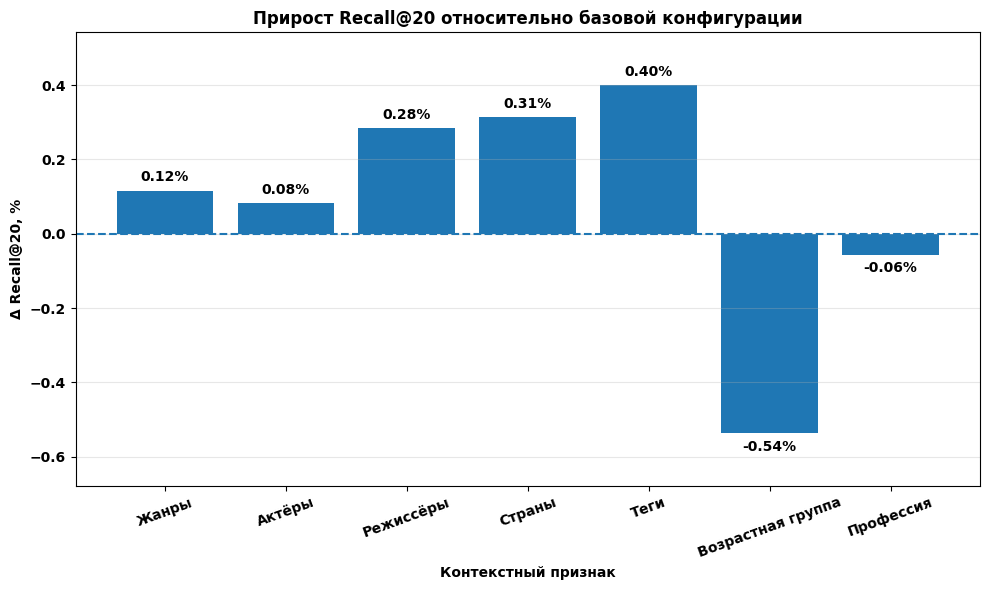

In [23]:
# ===== Δ Recall@20 относительно raw =====
recall_delta_df = delta_plot_df[delta_plot_df["metric"] == "recall"].copy()

# Переводим значения в проценты
recall_delta_df["delta_percent"] = recall_delta_df["delta_vs_raw"] * 100

plt.figure(figsize=(10, 6))

bars = plt.bar(
    recall_delta_df["feature_label"],
    recall_delta_df["delta_percent"]
)

plt.axhline(0, linestyle="--", linewidth=1.5)

plt.title(
    "Прирост Recall@20 относительно базовой конфигурации",
    fontweight="bold"
)
plt.xlabel("Контекстный признак", fontweight="bold")
plt.ylabel("Δ Recall@20, %", fontweight="bold")

plt.xticks(rotation=20, fontweight="bold")
plt.yticks(fontweight="bold")

# Подписи значений над/под столбцами
# ===== добавляем запас сверху и снизу =====
y_min = recall_delta_df["delta_percent"].min()
y_max = recall_delta_df["delta_percent"].max()
margin = (y_max - y_min) * 0.15 if y_max > y_min else 0.05

plt.ylim(y_min - margin, y_max + margin)

# ===== подписи значений =====
for bar in bars:
    value = bar.get_height()
    offset = margin * 0.12

    if value >= 0:
        y = value + offset
        va = "bottom"
    else:
        y = value - offset
        va = "top"

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        y,
        f"{value:.2f}%",
        ha="center",
        va=va,
        fontweight="bold"
    )

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

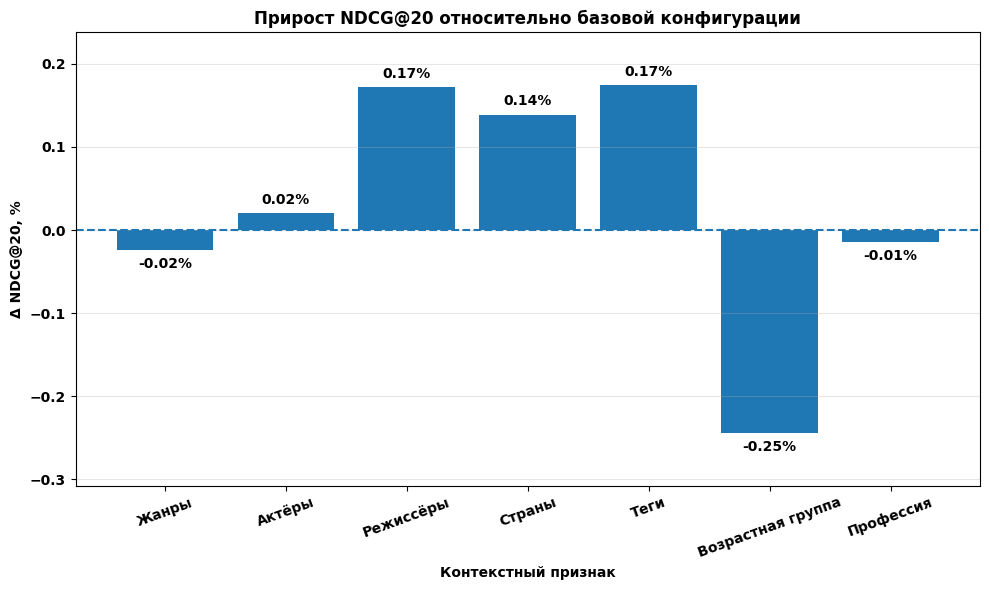

In [24]:
# ===== Δ NDCG@20 относительно raw =====
ndcg_delta_df = delta_plot_df[delta_plot_df["metric"] == "ndcg"].copy()

# Переводим значения в проценты
ndcg_delta_df["delta_percent"] = ndcg_delta_df["delta_vs_raw"] * 100

plt.figure(figsize=(10, 6))

bars = plt.bar(
    ndcg_delta_df["feature_label"],
    ndcg_delta_df["delta_percent"]
)

plt.axhline(0, linestyle="--", linewidth=1.5)

plt.title(
    "Прирост NDCG@20 относительно базовой конфигурации",
    fontweight="bold"
)
plt.xlabel("Контекстный признак", fontweight="bold")
plt.ylabel("Δ NDCG@20, %", fontweight="bold")

plt.xticks(rotation=20, fontweight="bold")
plt.yticks(fontweight="bold")

# ===== добавляем запас сверху и снизу =====
y_min = ndcg_delta_df["delta_percent"].min()
y_max = ndcg_delta_df["delta_percent"].max()
margin = (y_max - y_min) * 0.15 if y_max > y_min else 0.05

plt.ylim(y_min - margin, y_max + margin)

# ===== подписи значений =====
for bar in bars:
    value = bar.get_height()
    offset = margin * 0.12

    if value >= 0:
        y = value + offset
        va = "bottom"
    else:
        y = value - offset
        va = "top"

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        y,
        f"{value:.2f}%",
        ha="center",
        va=va,
        fontweight="bold"
    )

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()